# Comparing methods of hurricane forecast uncertainty
##### author: Elizabeth A. Barnes, Randal J. Barnes and Mark DeMaria

In [1]:
import sys
sys.path.append('..')

import datetime
import importlib as imp
import os
import pickle
import pprint
import random
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import tensorflow_probability as tfp
from sklearn import preprocessing
from silence_tensorflow import silence_tensorflow

from build_data import build_hurricane_data
import build_model
import experiment_settings
from save_model_run import save_model_run
from training_instrumentation import TrainingInstrumentation

In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "09 August 2022"

silence_tensorflow()
tf.config.set_visible_devices([], 'GPU') # turn-off tensorflow-metal if it is on

imp.reload(experiment_settings)

EXP_NAME_LIST = (
    "centered_bivariate_normal_101_EPCP24",
    
#     "centered_bivariate_normal_101_EPCP24",
#     "centered_bivariate_normal_102_EPCP48",
#     "centered_bivariate_normal_103_EPCP72",
#     "centered_bivariate_normal_104_EPCP96",
#     "centered_bivariate_normal_105_EPCP120",    
    
#     "centered_bivariate_normal_201_AL24",
#     "centered_bivariate_normal_202_AL48",
#     "centered_bivariate_normal_203_AL72",
#     "centered_bivariate_normal_204_AL96",
#     "centered_bivariate_normal_205_AL120",    
    
)

OVERWRITE_MODEL = False
DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"

In [3]:
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["figure.dpi"] = 150
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

## Loop through the defined experiments.

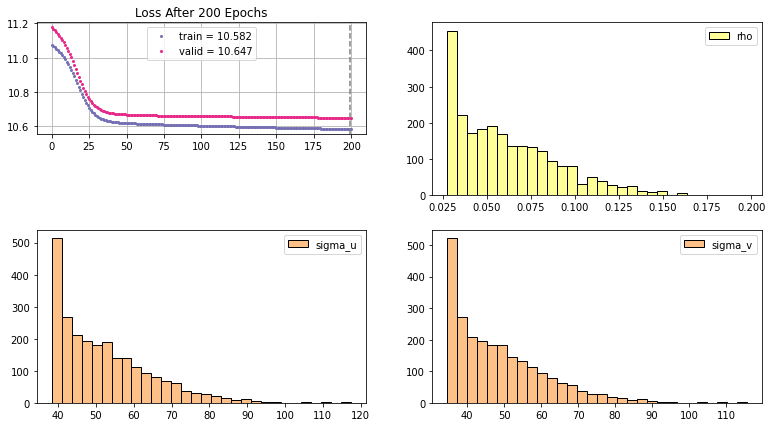


KeyboardInterrupt



In [4]:
imp.reload(build_model)

for exp_name in EXP_NAME_LIST:
    settings = experiment_settings.get_settings(exp_name)

    # set testing data
    if settings["test_condition"] == "leave-one-out":
        TESTING_YEARS_LIST = np.arange(2013,2022)
    elif settings["test_condition"] == "years":
        TESTING_YEARS_LIST = (np.copy(settings["years_test"]))
    else:
        raise NotImplementError('no such testing condition')
        
    for testing_years in TESTING_YEARS_LIST:        
        settings["years_test"] = (testing_years,)
        
        for rng_seed in settings['rng_seed_list']:
            settings['rng_seed'] = rng_seed

            #--------------------- RUN THE EXPERIMENT ---------------------------
            # Build the track data tensors for a bivariate normal model.
            (
                data_summary,        
                x_train,
                onehot_train,
                x_val,
                onehot_val,
                x_test,
                onehot_test,        
                x_valtest,
                onehot_valtest,
                df_train,
                df_val,
                df_test,
                df_valtest,
            ) = build_hurricane_data(DATA_PATH, settings, verbose=0)

            # Define the callbacks
            earlystoping_callback = tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=settings["patience"],
                restore_best_weights=True,
                verbose=1,
            )

            training_callback = TrainingInstrumentation(
                x_train,
                onehot_train,
                interval=50,
            )

            callbacks = [earlystoping_callback, 
                         training_callback,
                        ]

            # set network seed and train the model
            NETWORK_SEED_LIST = [settings["rng_seed"]]

            for network_seed in NETWORK_SEED_LIST:
                
                # set random seeds
                np.random.seed(rng_seed)
                random.seed(rng_seed)                            
                tf.random.set_seed(network_seed) 

                # Create the model name.
                model_name = (
                    exp_name + "_" + 
                    str(testing_years) + '_' +
                    settings["uncertainty_type"] + '_' + 
                    f"network_seed_{network_seed}_rng_seed_{settings['rng_seed']}"
                )
                
                # Make, compile, and train the model
                tf.keras.backend.clear_session()            
                model = build_model.make_model(
                    settings,
                    x_train,
                    onehot_train,
                    model_compile=True,
                )   
                # model.summary()

                # check if the model exists
                model_savename = MODEL_PATH + model_name + "_weights.h5"
                if os.path.exists(model_savename) and OVERWRITE_MODEL==False:
                    # print(model_savename + ' exists. Skipping...')
                    continue

                # train the network
                pprint.pprint(model_name)
                start_time = time.time()
                history = model.fit(
                    x_train,
                    onehot_train,
                    validation_data=(x_val, onehot_val),
                    batch_size=settings["batch_size"],
                    epochs=settings["n_epochs"],
                    shuffle=True,
                    verbose=0,
                    callbacks=callbacks,
                )
                stop_time = time.time()

                # Display the results, and save the model rum.
                best_epoch = np.argmin(history.history["val_loss"])
                fit_summary = {
                    "network_seed": network_seed,
                    "elapsed_time": stop_time - start_time,
                    "best_epoch": best_epoch,
                    "loss_train": history.history["loss"][best_epoch],
                    "loss_valid": history.history["val_loss"][best_epoch],
                }
                pprint.pprint(fit_summary, width=80)
                
                
                save_model_run(
                    data_summary,
                    fit_summary,
                    model,
                    MODEL_PATH,
                    model_name,
                    settings,
                    __version__,
                )


In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.axvline(x=best_epoch,color='k')